In [1]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/code")

from parse_gtf import *
from junction2psi import *

pd.set_option('display.max_columns', None)

## First cluster MEs themselves

In [2]:
ctype_abundance_df = pd.read_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance.csv", index_col=0)

In [3]:
ctype_abundance_df.head()

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Sample,,,,,,,,,,,,,,,,,,,,,,,,,,
GTEX.12126.0011.R10b.SM.5BC6T,-0.027389,-0.020109,-0.040076,-0.024553,0.032487,0.006274,0.088285,-0.022679,-0.026597,-0.040076,-0.020109,-0.051868,0.144676,-0.045363,-0.051565,-0.012470,-0.034361,0.078298,-0.034733,-0.009510,0.078921,-0.030844,-0.009510,0.062970,-0.036232,-0.044717
GTEX.12126.0011.R3b.SM.GJ3RE,-0.034537,-0.024565,0.004521,-0.017468,0.031393,0.033200,0.014653,-0.008414,-0.034164,0.004521,-0.024565,-0.066528,-0.014015,-0.066424,-0.027182,0.001876,-0.028788,0.040907,-0.065498,-0.008888,0.041221,-0.059097,-0.008888,0.006659,-0.067439,0.045162
GTEX.12126.1026.SM.5P9JJ,-0.011368,-0.030623,-0.004060,-0.032128,-0.011833,0.049281,0.050092,0.067889,-0.010280,-0.004060,-0.030623,-0.008997,0.011209,0.004694,-0.010406,-0.003790,-0.027773,0.051572,0.033054,0.062719,0.051763,0.024251,0.062719,0.060164,0.032106,0.065797
GTEX.12WSE.0011.R3a.SM.GIN9S,-0.031131,0.006512,-0.035160,0.025898,0.035820,0.012791,0.155860,0.008562,-0.031341,-0.035160,0.006512,-0.028079,0.079146,-0.026999,-0.036626,0.046987,0.044925,0.147209,0.049445,0.041387,0.146882,0.056045,0.041387,0.117445,0.052985,-0.003168
GTEX.15ER7.0011.R3a.SM.6LPIK,-0.030652,0.005926,-0.037842,0.006903,0.046518,-0.014621,0.044945,-0.037287,-0.030310,-0.037842,0.005926,-0.019883,0.020049,-0.013883,-0.042440,0.007209,0.001873,0.049889,-0.029951,-0.023440,0.049447,-0.011527,-0.023440,0.004162,-0.031119,-0.024795


In [4]:
abund_corr_mat = ctype_abundance_df.corr()

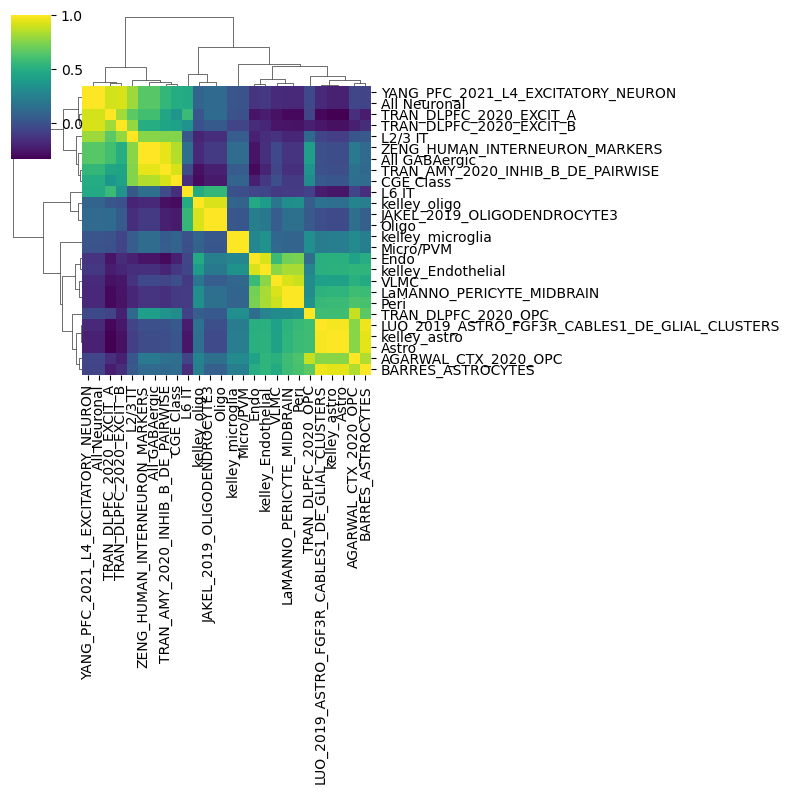

In [5]:
sns.clustermap(abund_corr_mat, cmap='viridis', method='ward', figsize=(8, 8))

## Gene expression corr clustering

In [6]:
expr_corr_df = pd.read_csv("data/corrs/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_gene_expr_corr.csv", index_col=0)

In [7]:
expr_corr_df.head()

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
5S_rRNA,0.143395,0.019099,-0.083847,0.018168,-0.019828,0.151468,0.088607,0.128741,0.143568,-0.083847,0.019099,-0.018881,0.050017,-0.021133,-0.064105,-0.005345,0.019281,0.113517,-0.046787,0.156236,0.113705,-0.057854,0.156236,0.154598,-0.041302,0.037459
5_8S_rRNA,0.071952,0.001660,-0.016265,0.019963,0.043398,0.061319,0.122449,0.047218,0.074401,-0.016265,0.001660,0.000352,0.092423,-0.007033,-0.015250,0.020922,0.028613,0.128165,-0.037700,0.063453,0.127862,-0.037389,0.063453,0.077323,-0.037311,0.023519
7SK,-0.033730,0.012173,0.031057,0.033162,0.010327,0.021552,0.042980,0.034135,-0.034212,0.031057,0.012173,-0.018118,0.018007,-0.011561,0.027884,0.026686,0.039433,0.064756,0.007356,0.049035,0.064494,0.033431,0.049035,0.038047,-0.004496,0.055557
A1BG,0.174432,0.224893,0.189259,0.277700,0.485087,0.302052,0.455097,0.345381,0.172073,0.189259,0.224893,0.038310,0.385136,0.105538,0.200378,0.464258,0.400683,0.536340,0.083546,0.432283,0.535027,0.097177,0.432283,0.494010,0.100613,0.205803
A1BG-AS1,-0.058321,-0.342934,0.122940,-0.322080,-0.153541,0.822096,0.495128,0.870950,-0.059354,0.122940,-0.342934,-0.209528,0.410480,-0.194128,0.060064,-0.189239,-0.219270,0.573266,-0.225150,0.894040,0.573141,-0.188535,0.894040,0.727392,-0.234715,0.466322


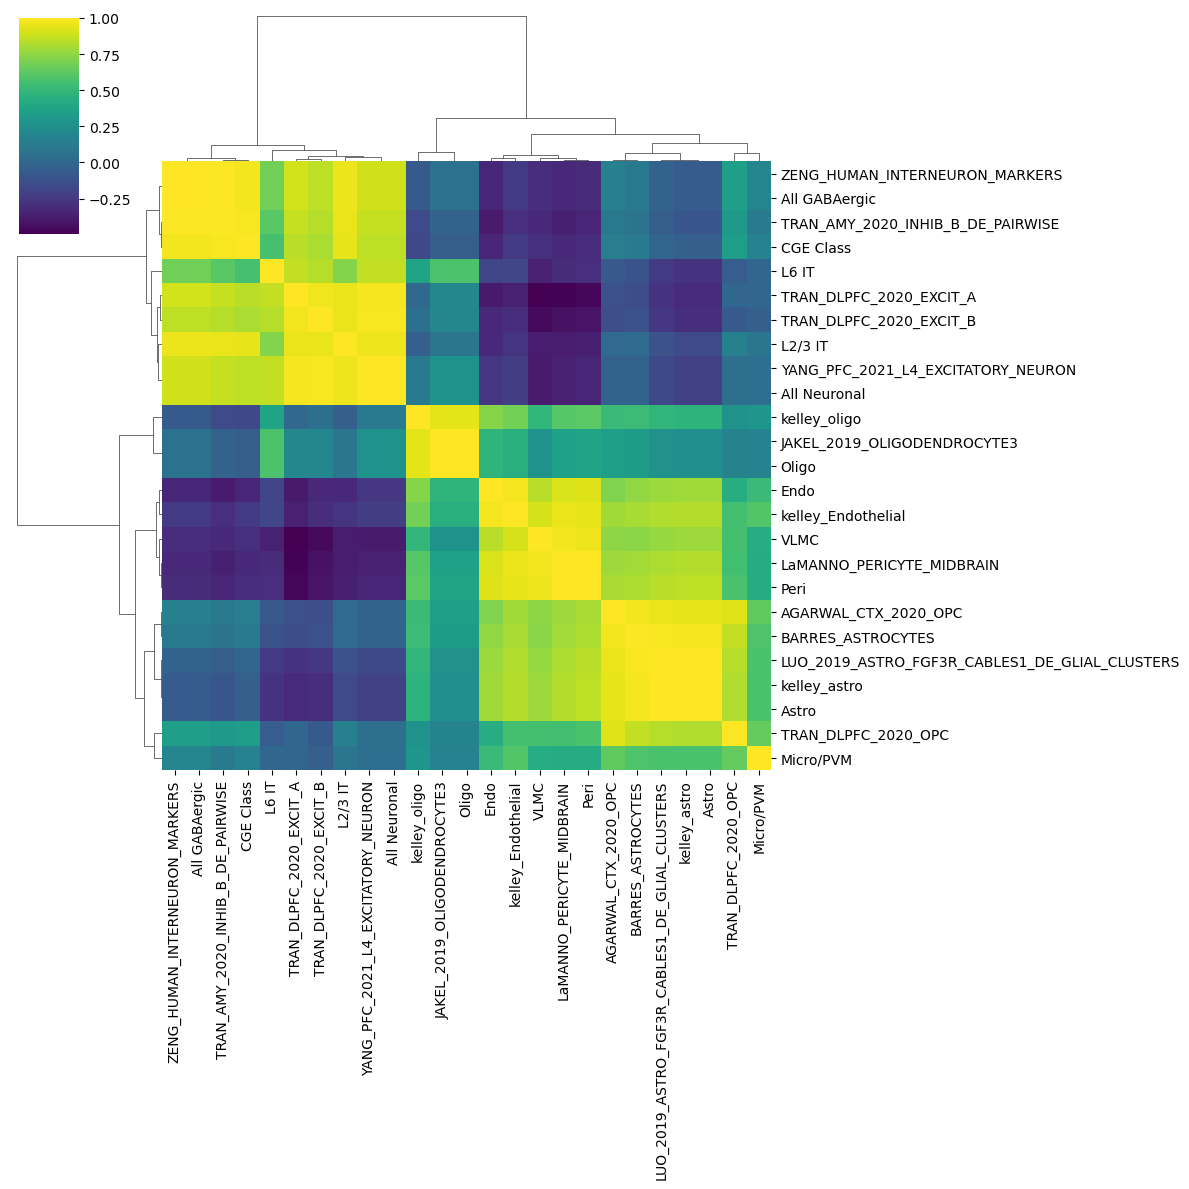

In [8]:
expr_corr_mat = expr_corr_df.iloc[:, 1:].corr()
sns.clustermap(expr_corr_mat, cmap='viridis', method='ward', figsize=(12, 12))

## Look at top genes for each module

In [9]:
keep = []

In [10]:
expr_corr_df.sort_values("CGE Class", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
SP8,0.106513,0.102942,-0.288628,0.108952,0.365611,0.251546,0.879974,0.312910,0.110612,-0.288628,0.102942,-0.164862,0.941894,-0.074813,-0.321572,0.192209,0.190225,0.800361,-0.071106,0.373999,0.801180,0.008079,0.373999,0.663420,-0.071386,-0.222888
RELN,0.057487,-0.017890,-0.210440,-0.010939,0.227241,0.277714,0.817064,0.345009,0.061167,-0.210440,-0.017890,-0.205287,0.928708,-0.123356,-0.268695,0.058992,0.064218,0.742217,-0.129283,0.380545,0.743223,-0.042812,0.380545,0.665689,-0.135356,-0.173562
CALB2,0.122704,0.119258,-0.287588,0.138647,0.377766,0.218339,0.870365,0.366520,0.127157,-0.287588,0.119258,-0.169100,0.913339,-0.084953,-0.311075,0.234073,0.233800,0.776776,-0.063073,0.388958,0.777392,0.013408,0.388958,0.704827,-0.061310,-0.241042
DLX1,0.086808,0.008432,-0.220508,0.023915,0.391302,0.440723,0.974607,0.406580,0.090044,-0.220508,0.008432,-0.308796,0.898565,-0.200295,-0.296959,0.175417,0.131316,0.947073,-0.170026,0.513988,0.947301,-0.068969,0.513988,0.717621,-0.166317,-0.029883
DLX6-AS1,0.045348,-0.009299,-0.212414,0.000991,0.372389,0.364952,0.955473,0.313470,0.048594,-0.212414,-0.009299,-0.282342,0.898023,-0.176815,-0.275797,0.165261,0.107816,0.898903,-0.115737,0.451753,0.899469,-0.022536,0.451753,0.678173,-0.114798,-0.083030
NPR3,0.158057,0.047651,-0.186848,0.053288,0.325010,0.357347,0.800314,0.348237,0.160980,-0.186848,0.047651,-0.145013,0.896797,-0.026278,-0.228215,0.179946,0.133474,0.756455,-0.046948,0.455146,0.757203,0.047236,0.455146,0.664781,-0.059535,-0.128708
SLC10A4,0.018690,-0.022470,-0.128316,0.001720,0.251551,0.565565,0.845652,0.547632,0.019853,-0.128316,-0.022470,-0.260997,0.895588,-0.163609,-0.214475,0.111686,0.101240,0.816605,-0.130316,0.628385,0.817072,-0.048089,0.628385,0.755023,-0.130524,0.050595
CHRNA6,0.030662,-0.095028,-0.205256,-0.084862,0.160042,0.362200,0.819535,0.399139,0.033225,-0.205256,-0.095028,-0.237987,0.894659,-0.156777,-0.257150,0.012674,0.003979,0.754303,-0.141236,0.453896,0.755338,-0.049760,0.453896,0.662498,-0.150930,-0.095769
PRLHR,0.038709,-0.070825,-0.145928,-0.053245,0.286004,0.476083,0.944191,0.449796,0.040402,-0.145928,-0.070825,-0.301771,0.883040,-0.210576,-0.225601,0.101618,0.057592,0.902637,-0.167200,0.553354,0.903156,-0.083504,0.553354,0.708338,-0.165013,0.029277


In [11]:
keep.append("CGE Class")

In [12]:
expr_corr_df.sort_values("ZENG_HUMAN_INTERNEURON_MARKERS", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
GAD1,0.148274,-0.143035,-0.127964,-0.122474,0.298368,0.627353,0.875041,0.459701,0.149339,-0.127964,-0.143035,-0.334304,0.767714,-0.244607,-0.234786,0.060774,-0.023831,0.947156,-0.272331,0.607024,0.947213,-0.189520,0.607024,0.693561,-0.271098,0.156551
DLX1,0.086808,0.008432,-0.220508,0.023915,0.391302,0.440723,0.974607,0.406580,0.090044,-0.220508,0.008432,-0.308796,0.898565,-0.200295,-0.296959,0.175417,0.131316,0.947073,-0.170026,0.513988,0.947301,-0.068969,0.513988,0.717621,-0.166317,-0.029883
GAD2,0.110598,-0.143265,-0.137508,-0.125291,0.292653,0.607923,0.880936,0.437714,0.112414,-0.137508,-0.143265,-0.360965,0.781463,-0.262520,-0.252004,0.046709,-0.027668,0.945140,-0.271201,0.580132,0.945328,-0.174788,0.580132,0.677975,-0.270954,0.145774
BTBD11,0.110793,-0.063016,-0.160749,-0.044772,0.271201,0.637216,0.899253,0.561151,0.111243,-0.160749,-0.063016,-0.296928,0.818316,-0.209224,-0.239732,0.088376,0.057840,0.940804,-0.222068,0.677352,0.941115,-0.144722,0.677352,0.758405,-0.217918,0.114942
ZNF385D,0.108942,-0.103405,-0.059601,-0.085043,0.335940,0.673221,0.840709,0.455441,0.109332,-0.059601,-0.103405,-0.317309,0.724591,-0.206174,-0.170405,0.114171,0.017825,0.930758,-0.211515,0.629443,0.930794,-0.121720,0.629443,0.652802,-0.208724,0.261009
DLX6,0.118925,-0.094890,-0.167860,-0.071658,0.274647,0.558048,0.902246,0.509696,0.121401,-0.167860,-0.094890,-0.297112,0.798528,-0.217879,-0.241406,0.079470,0.035464,0.925782,-0.216814,0.610273,0.925847,-0.133317,0.610273,0.724554,-0.217865,0.079916
MYO16,0.155515,0.062727,-0.069203,0.084802,0.456776,0.594752,0.831932,0.501376,0.156327,-0.069203,0.062727,-0.165788,0.683352,-0.091431,-0.098922,0.308385,0.202033,0.908856,-0.086011,0.651388,0.908598,-0.043756,0.651388,0.722736,-0.073842,0.202908
SIAH3,0.027231,-0.186285,-0.054190,-0.168717,0.181103,0.690323,0.865534,0.633354,0.028302,-0.054190,-0.186285,-0.305693,0.746516,-0.241253,-0.133386,-0.000196,-0.056496,0.907815,-0.255127,0.742820,0.908105,-0.182032,0.742820,0.766573,-0.256192,0.252371
NXPH1,0.195688,0.085902,-0.092476,0.104743,0.612831,0.467495,0.824901,0.261375,0.197469,-0.092476,0.085902,-0.258384,0.709431,-0.135919,-0.189056,0.357300,0.207598,0.907757,-0.135099,0.438100,0.907545,-0.061061,0.438100,0.570706,-0.125813,0.107780


In [13]:
expr_corr_df.sort_values("All GABAergic", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
DLX1,0.086808,0.008432,-0.220508,0.023915,0.391302,0.440723,0.974607,0.406580,0.090044,-0.220508,0.008432,-0.308796,0.898565,-0.200295,-0.296959,0.175417,0.131316,0.947073,-0.170026,0.513988,0.947301,-0.068969,0.513988,0.717621,-0.166317,-0.029883
GAD1,0.148274,-0.143035,-0.127964,-0.122474,0.298368,0.627353,0.875041,0.459701,0.149339,-0.127964,-0.143035,-0.334304,0.767714,-0.244607,-0.234786,0.060774,-0.023831,0.947156,-0.272331,0.607024,0.947213,-0.189520,0.607024,0.693561,-0.271098,0.156551
GAD2,0.110598,-0.143265,-0.137508,-0.125291,0.292653,0.607923,0.880936,0.437714,0.112414,-0.137508,-0.143265,-0.360965,0.781463,-0.262520,-0.252004,0.046709,-0.027668,0.945140,-0.271201,0.580132,0.945328,-0.174788,0.580132,0.677975,-0.270954,0.145774
BTBD11,0.110793,-0.063016,-0.160749,-0.044772,0.271201,0.637216,0.899253,0.561151,0.111243,-0.160749,-0.063016,-0.296928,0.818316,-0.209224,-0.239732,0.088376,0.057840,0.940804,-0.222068,0.677352,0.941115,-0.144722,0.677352,0.758405,-0.217918,0.114942
ZNF385D,0.108942,-0.103405,-0.059601,-0.085043,0.335940,0.673221,0.840709,0.455441,0.109332,-0.059601,-0.103405,-0.317309,0.724591,-0.206174,-0.170405,0.114171,0.017825,0.930758,-0.211515,0.629443,0.930794,-0.121720,0.629443,0.652802,-0.208724,0.261009
DLX6,0.118925,-0.094890,-0.167860,-0.071658,0.274647,0.558048,0.902246,0.509696,0.121401,-0.167860,-0.094890,-0.297112,0.798528,-0.217879,-0.241406,0.079470,0.035464,0.925782,-0.216814,0.610273,0.925847,-0.133317,0.610273,0.724554,-0.217865,0.079916
MYO16,0.155515,0.062727,-0.069203,0.084802,0.456776,0.594752,0.831932,0.501376,0.156327,-0.069203,0.062727,-0.165788,0.683352,-0.091431,-0.098922,0.308385,0.202033,0.908856,-0.086011,0.651388,0.908598,-0.043756,0.651388,0.722736,-0.073842,0.202908
SIAH3,0.027231,-0.186285,-0.054190,-0.168717,0.181103,0.690323,0.865534,0.633354,0.028302,-0.054190,-0.186285,-0.305693,0.746516,-0.241253,-0.133386,-0.000196,-0.056496,0.907815,-0.255127,0.742820,0.908105,-0.182032,0.742820,0.766573,-0.256192,0.252371
NXPH1,0.195688,0.085902,-0.092476,0.104743,0.612831,0.467495,0.824901,0.261375,0.197469,-0.092476,0.085902,-0.258384,0.709431,-0.135919,-0.189056,0.357300,0.207598,0.907757,-0.135099,0.438100,0.907545,-0.061061,0.438100,0.570706,-0.125813,0.107780


In [14]:
# Let's just keep the "All GABAergic"

In [15]:
keep.append("All GABAergic")

In [16]:
expr_corr_df['L6 IT'].corr(expr_corr_df['Oligo'])

0.5753524456868027

In [17]:
expr_corr_df['All Neuronal'].corr(expr_corr_df['L6 IT'])

0.8608175766651808

In [18]:
expr_corr_df.sort_values("L6 IT", ascending=False).head(60)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
MCTP2,0.042704,-0.153869,0.504292,-0.137348,-0.015741,0.495642,0.001997,0.264214,0.038316,0.504292,-0.153869,0.050003,-0.081431,0.042791,0.447676,0.007523,-0.076169,0.155221,-0.016081,0.395267,0.154589,-0.036949,0.395267,0.016234,-0.017193,0.893239
ENSG00000278913,-0.078679,-0.275017,0.500236,-0.257822,-0.144315,0.566266,-0.001157,0.399509,-0.084497,0.500236,-0.275017,-0.114003,-0.097777,-0.132724,0.416549,-0.141570,-0.194069,0.139212,-0.178155,0.510075,0.138858,-0.195008,0.510075,0.082971,-0.174124,0.862572
HS3ST4,0.082388,-0.190558,0.412016,-0.168339,0.078191,0.622320,0.180199,0.438766,0.077263,0.412016,-0.190558,-0.134012,0.015925,-0.136183,0.359278,0.021053,-0.091980,0.355596,-0.184603,0.556746,0.354687,-0.183062,0.556746,0.205118,-0.178177,0.851644
RXFP1,-0.063842,-0.347128,0.341450,-0.324359,-0.090574,0.787790,0.163699,0.514704,-0.069510,0.341450,-0.347128,-0.225205,0.032977,-0.212983,0.230990,-0.154838,-0.256552,0.342823,-0.266519,0.668237,0.342233,-0.254024,0.668237,0.254691,-0.264338,0.849320
ADTRP,-0.087411,-0.328798,0.411471,-0.304297,-0.114546,0.693809,0.156516,0.495055,-0.092972,0.411471,-0.328798,-0.203355,0.013589,-0.215127,0.336231,-0.136111,-0.225707,0.309312,-0.224366,0.645019,0.308624,-0.217525,0.645019,0.241612,-0.221255,0.841362
SEMA3E,0.003626,-0.154210,0.452280,-0.132249,0.163136,0.557315,0.060636,0.225501,-0.001694,0.452280,-0.154210,-0.116492,-0.075142,-0.088917,0.336970,0.096723,-0.065728,0.247861,-0.108924,0.375961,0.246812,-0.120167,0.375961,0.019749,-0.101224,0.837035
THEMIS,0.015950,-0.225647,0.403343,-0.207019,0.042630,0.614149,0.052495,0.304576,0.011651,0.403343,-0.225647,-0.163720,-0.055295,-0.146878,0.279590,-0.066031,-0.154921,0.242970,-0.223894,0.431548,0.242098,-0.216474,0.431548,0.062754,-0.220215,0.835166
IQCF4P,-0.034678,-0.238385,0.454424,-0.222020,-0.091559,0.438059,-0.047507,0.266413,-0.040305,0.454424,-0.238385,-0.075361,-0.162388,-0.096125,0.401876,-0.068935,-0.168796,0.088016,-0.126951,0.369220,0.087359,-0.146006,0.369220,-0.027937,-0.122067,0.830581
SMIM32,-0.025931,-0.204879,0.401825,-0.178356,-0.032456,0.463279,0.003737,0.280267,-0.029819,0.401825,-0.204879,-0.105727,-0.123313,-0.118906,0.326564,-0.046227,-0.116619,0.160978,-0.119356,0.358393,0.160033,-0.130291,0.358393,0.013988,-0.113782,0.825953


In [20]:
expr_corr_df.sort_values("L6 IT", ascending=False).head(30)['L6 IT']

Gene
MCTP2              0.893239
ENSG00000278913    0.862572
HS3ST4             0.851644
RXFP1              0.849320
ADTRP              0.841362
SEMA3E             0.837035
THEMIS             0.835166
IQCF4P             0.830581
SMIM32             0.825953
FOXP2              0.810924
GALNT14            0.799134
PRKCQ              0.785626
SMYD1              0.783140
GRIK3              0.774632
IQCF3              0.771607
ENSG00000260848    0.771400
CHN2               0.769311
MEI1               0.748135
ENSG00000285933    0.745916
KRT17              0.737151
B3GALT2            0.733833
DACH1              0.731969
NPFFR2             0.730204
POSTN              0.725706
ENSG00000286685    0.718682
DPP4               0.718327
TLE4               0.711512
CLSTN2             0.711353
LINC00343          0.711125
HS3ST5             0.709083
Name: L6 IT, dtype: float64

In [221]:
# Looks like it could represent deep layer neurons

keep.append("L6 IT")

In [222]:
expr_corr_df.sort_values("TRAN_DLPFC_2020_EXCIT_A", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
DCLK1,0.024992,-0.347256,0.061887,-0.324175,-0.023258,0.973850,0.509242,0.740373,0.024580,0.061887,-0.347256,-0.298756,0.432289,-0.253141,-0.057163,-0.159437,-0.240260,0.652762,-0.329551,0.853323,0.652637,-0.280619,0.853323,0.650740,-0.332137,0.504335
NUAK1,-0.020080,-0.362478,0.111351,-0.345676,-0.119204,0.969849,0.479974,0.827720,-0.021367,0.111351,-0.362478,-0.269617,0.409135,-0.234169,0.009282,-0.194937,-0.256252,0.599128,-0.290729,0.905014,0.599224,-0.252965,0.905014,0.672262,-0.293289,0.528680
MOAP1,0.052669,-0.283219,0.066162,-0.255794,-0.034538,0.968600,0.547854,0.842655,0.052359,0.066162,-0.283219,-0.256206,0.483535,-0.221068,-0.033707,-0.135262,-0.169176,0.676762,-0.298421,0.917147,0.676664,-0.259107,0.917147,0.733685,-0.299619,0.482890
NEFL,0.011764,-0.344387,0.032782,-0.324136,-0.117926,0.968026,0.460067,0.837548,0.011494,0.032782,-0.344387,-0.269398,0.397112,-0.248067,-0.061141,-0.215868,-0.249847,0.582544,-0.327453,0.888306,0.582495,-0.290884,0.888306,0.681886,-0.329345,0.442729
PDK3,0.053448,-0.281337,0.041453,-0.256833,-0.028045,0.967265,0.508043,0.809730,0.052348,0.041453,-0.281337,-0.237005,0.442964,-0.202032,-0.041194,-0.122121,-0.174176,0.640869,-0.287698,0.903111,0.640811,-0.248702,0.903111,0.733858,-0.292230,0.450121
GOT1,0.013357,-0.331470,0.083444,-0.302407,-0.080754,0.966436,0.531330,0.859476,0.011913,0.083444,-0.331470,-0.284912,0.457288,-0.257857,-0.027037,-0.175898,-0.214026,0.654650,-0.327404,0.917671,0.654546,-0.291369,0.917671,0.726432,-0.328555,0.489743
ATP6V1B2,0.035989,-0.289401,0.061172,-0.259700,-0.019077,0.966171,0.536585,0.835983,0.034450,0.061172,-0.289401,-0.284831,0.472169,-0.249932,-0.044951,-0.130686,-0.169203,0.665159,-0.340321,0.909131,0.665029,-0.298969,0.909131,0.738947,-0.340276,0.470425
MAP7D2,0.016645,-0.307203,0.026939,-0.284725,0.006513,0.964226,0.599608,0.823731,0.015989,0.026939,-0.307203,-0.317819,0.522188,-0.272027,-0.085103,-0.130680,-0.188985,0.722300,-0.333686,0.911516,0.722194,-0.284765,0.911516,0.760735,-0.333529,0.444211
KIFAP3,0.003206,-0.217984,0.121971,-0.186526,0.019236,0.964088,0.509046,0.829944,0.001565,0.121971,-0.217984,-0.219843,0.450075,-0.183128,0.025432,-0.061436,-0.091893,0.637023,-0.260000,0.914516,0.636945,-0.234483,0.914516,0.719417,-0.257722,0.513532


In [223]:
# Looks more generally neuronal... 

In [224]:
expr_corr_df.sort_values("TRAN_DLPFC_2020_EXCIT_B", ascending=False).head(30)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
PHYHIP,-0.066035,-0.296304,0.030007,-0.266949,-0.216706,0.817170,0.430786,0.989804,-0.067142,0.030007,-0.296304,-0.182745,0.398838,-0.204649,-0.010431,-0.217582,-0.186470,0.485477,-0.280421,0.912155,0.485353,-0.272117,0.912155,0.774504,-0.282515,0.365593
CAMKK1,-0.067176,-0.304007,0.050345,-0.284690,-0.268228,0.798326,0.407102,0.979361,-0.068272,0.050345,-0.304007,-0.171573,0.399093,-0.195714,0.007234,-0.262593,-0.206293,0.445954,-0.275755,0.896781,0.446046,-0.267387,0.896781,0.749982,-0.279289,0.343451
NCDN,-0.026901,-0.230340,0.009427,-0.207133,-0.181140,0.779444,0.453367,0.978299,-0.026540,0.009427,-0.230340,-0.134239,0.429125,-0.164352,-0.015790,-0.183347,-0.128846,0.501919,-0.250900,0.884640,0.502005,-0.251218,0.884640,0.782202,-0.253073,0.312628
PRRT2,-0.081245,-0.253163,0.066901,-0.226570,-0.183270,0.807932,0.456200,0.975759,-0.082741,0.066901,-0.253163,-0.160827,0.431759,-0.166689,0.015544,-0.178021,-0.132166,0.506597,-0.227472,0.913949,0.506539,-0.219985,0.913949,0.774492,-0.227275,0.369324
FAIM2,-0.087749,-0.217736,0.124346,-0.189677,-0.155983,0.837970,0.408996,0.957627,-0.089413,0.124346,-0.217736,-0.120540,0.344695,-0.146917,0.091770,-0.124852,-0.098894,0.483560,-0.198876,0.917717,0.483451,-0.216273,0.917717,0.710549,-0.193389,0.449692
ACTL6B,-0.055739,-0.367277,0.057723,-0.338513,-0.202930,0.856419,0.498290,0.956286,-0.056694,0.057723,-0.367277,-0.248217,0.449353,-0.252690,-0.020352,-0.240964,-0.240471,0.563187,-0.308198,0.919414,0.563057,-0.284137,0.919414,0.759569,-0.313088,0.408613
UBE2O,-0.061412,-0.291609,0.115305,-0.271277,-0.208675,0.853658,0.421176,0.955066,-0.063559,0.115305,-0.291609,-0.119451,0.362919,-0.148892,0.093293,-0.180450,-0.172986,0.494688,-0.214933,0.943130,0.494732,-0.225359,0.943130,0.730878,-0.215604,0.448183
PDE1B,-0.085375,-0.264282,0.084446,-0.242715,-0.291215,0.745262,0.334664,0.954178,-0.088173,0.084446,-0.264282,-0.086265,0.331267,-0.119661,0.070119,-0.225022,-0.164576,0.366703,-0.201731,0.882914,0.366917,-0.214882,0.882914,0.707017,-0.201125,0.334410
DNM1,-0.100462,-0.365800,0.103755,-0.340720,-0.237494,0.868842,0.412895,0.953525,-0.102414,0.103755,-0.365800,-0.209491,0.342960,-0.229499,0.045083,-0.241758,-0.246821,0.488324,-0.282498,0.928710,0.488131,-0.276506,0.928710,0.709420,-0.285009,0.475074


In [225]:
# Not convincingly purely excitatory.

In [226]:
expr_corr_df.sort_values("L2/3 IT", ascending=False).head(30)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
TUNAR,0.039753,-0.085144,-0.155838,-0.059736,0.087307,0.619976,0.685923,0.735000,0.041646,-0.155838,-0.085144,-0.226441,0.672388,-0.190759,-0.206154,-0.010637,0.017610,0.704076,-0.214991,0.723581,0.704231,-0.168366,0.723581,0.916155,-0.215159,0.029759
HS6ST3,0.031924,-0.185110,-0.146371,-0.171118,0.016479,0.794470,0.664475,0.816559,0.033054,-0.146371,-0.185110,-0.261960,0.679672,-0.213829,-0.223332,-0.101178,-0.095662,0.701653,-0.275714,0.829413,0.702275,-0.223787,0.829413,0.908894,-0.278366,0.109888
GNAL,0.173820,0.047526,-0.160696,0.066993,0.303252,0.601706,0.807855,0.655100,0.175813,-0.160696,0.047526,-0.172278,0.789281,-0.102158,-0.197524,0.164662,0.162885,0.841941,-0.152632,0.707523,0.842242,-0.099576,0.707523,0.906711,-0.152079,0.007833
PCDH8,-0.007270,-0.173093,-0.224698,-0.154058,0.015946,0.664029,0.728155,0.753422,-0.005916,-0.224698,-0.173093,-0.284097,0.746005,-0.238062,-0.292828,-0.093743,-0.073374,0.716649,-0.267204,0.739303,0.717192,-0.209071,0.739303,0.903916,-0.270253,-0.038629
LINC01476,0.007827,-0.137956,-0.103828,-0.099321,0.146797,0.644964,0.733204,0.723810,0.008913,-0.103828,-0.137956,-0.300341,0.663185,-0.244441,-0.173105,0.008298,0.000078,0.767596,-0.230989,0.755105,0.767430,-0.167492,0.755105,0.903840,-0.231404,0.137644
AKAP5,0.065398,-0.147885,-0.104483,-0.127478,0.137155,0.760449,0.700388,0.739869,0.066207,-0.104483,-0.147885,-0.282524,0.722006,-0.212314,-0.200407,-0.031757,-0.048107,0.750692,-0.289670,0.798009,0.751110,-0.221442,0.798009,0.899106,-0.294919,0.154738
GALNTL6,0.098755,-0.114479,-0.160801,-0.084098,0.259950,0.658831,0.833305,0.640586,0.099734,-0.160801,-0.114479,-0.294297,0.794637,-0.220115,-0.244389,0.075813,0.019388,0.880429,-0.251811,0.721548,0.880401,-0.171671,0.721548,0.897017,-0.254973,0.110205
KCNN2,0.005685,-0.078772,-0.042279,-0.049346,0.097432,0.662462,0.677046,0.769774,0.004836,-0.042279,-0.078772,-0.157714,0.653657,-0.119327,-0.076633,0.055159,0.069185,0.695486,-0.130079,0.809011,0.695483,-0.094112,0.809011,0.895637,-0.128537,0.121926
SSTR1,0.044992,-0.080013,-0.101406,-0.052280,0.261197,0.685642,0.720871,0.706752,0.047265,-0.101406,-0.080013,-0.193667,0.682021,-0.129839,-0.161565,0.132757,0.045044,0.774611,-0.160249,0.761476,0.774762,-0.111866,0.761476,0.895069,-0.160938,0.144106


In [227]:
# If anything, maybe more general neuronal?

In [228]:
expr_corr_df.sort_values("YANG_PFC_2021_L4_EXCITATORY_NEURON", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
KALRN,0.012156,-0.193280,0.072394,-0.167764,-0.070389,0.907280,0.502219,0.913441,0.010734,0.072394,-0.193280,-0.147379,0.452461,-0.147408,0.033892,-0.095788,-0.085811,0.596335,-0.233560,0.962853,0.596525,-0.229533,0.962853,0.802879,-0.231270,0.447862
SPATS2,0.054062,-0.225651,0.088603,-0.198945,-0.005646,0.935104,0.549746,0.884611,0.051758,0.088603,-0.225651,-0.175321,0.487828,-0.153657,0.026938,-0.058912,-0.096392,0.664547,-0.234876,0.962574,0.664482,-0.219872,0.962574,0.802740,-0.233016,0.450747
ADD2,-0.023556,-0.295377,0.062334,-0.270056,-0.049675,0.929035,0.586487,0.903441,-0.024912,0.062334,-0.295377,-0.257834,0.497490,-0.237440,-0.012621,-0.133897,-0.165836,0.681002,-0.296823,0.962553,0.680840,-0.267061,0.962553,0.807887,-0.295678,0.471564
AAK1,0.022761,-0.248382,0.081928,-0.230826,-0.038728,0.954073,0.550843,0.862628,0.020156,0.081928,-0.248382,-0.189113,0.488094,-0.164430,0.019374,-0.100695,-0.134056,0.657628,-0.252203,0.960717,0.657794,-0.232931,0.960717,0.766468,-0.249974,0.470673
PRDM2,-0.033225,-0.231129,0.193758,-0.211469,-0.138864,0.892392,0.437609,0.923104,-0.036486,0.193758,-0.231129,-0.097916,0.403993,-0.093473,0.151651,-0.114998,-0.115397,0.528570,-0.170298,0.959738,0.528790,-0.175114,0.959738,0.727281,-0.168494,0.510315
GRIPAP1,0.018264,-0.194480,0.161367,-0.163976,-0.043855,0.866050,0.514536,0.909510,0.015956,0.161367,-0.194480,-0.089349,0.420883,-0.096323,0.142270,-0.044352,-0.051103,0.618181,-0.168798,0.959345,0.617917,-0.176772,0.959345,0.745633,-0.163373,0.482743
GNB5,0.035047,-0.184920,0.042980,-0.159134,0.004889,0.942820,0.577452,0.882040,0.033604,0.042980,-0.184920,-0.191560,0.516613,-0.156691,-0.018195,-0.054425,-0.066663,0.684975,-0.228530,0.955392,0.684921,-0.204989,0.955392,0.787458,-0.224721,0.432510
GOT2,0.015643,-0.226914,0.097359,-0.194533,-0.086126,0.925123,0.511847,0.926428,0.013464,0.097359,-0.226914,-0.162929,0.471783,-0.151174,0.028821,-0.116989,-0.109536,0.607865,-0.242558,0.954771,0.607944,-0.230252,0.954771,0.797473,-0.242313,0.422692
MYH10,-0.033804,-0.209263,0.051196,-0.190640,-0.022160,0.928578,0.562053,0.888274,-0.034671,0.051196,-0.209263,-0.190668,0.492734,-0.168314,-0.009221,-0.071829,-0.089571,0.663254,-0.216043,0.954046,0.663305,-0.199060,0.954046,0.797054,-0.214696,0.443302


In [229]:
expr_corr_df.sort_values("All Neuronal", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
KALRN,0.012156,-0.193280,0.072394,-0.167764,-0.070389,0.907280,0.502219,0.913441,0.010734,0.072394,-0.193280,-0.147379,0.452461,-0.147408,0.033892,-0.095788,-0.085811,0.596335,-0.233560,0.962853,0.596525,-0.229533,0.962853,0.802879,-0.231270,0.447862
SPATS2,0.054062,-0.225651,0.088603,-0.198945,-0.005646,0.935104,0.549746,0.884611,0.051758,0.088603,-0.225651,-0.175321,0.487828,-0.153657,0.026938,-0.058912,-0.096392,0.664547,-0.234876,0.962574,0.664482,-0.219872,0.962574,0.802740,-0.233016,0.450747
ADD2,-0.023556,-0.295377,0.062334,-0.270056,-0.049675,0.929035,0.586487,0.903441,-0.024912,0.062334,-0.295377,-0.257834,0.497490,-0.237440,-0.012621,-0.133897,-0.165836,0.681002,-0.296823,0.962553,0.680840,-0.267061,0.962553,0.807887,-0.295678,0.471564
AAK1,0.022761,-0.248382,0.081928,-0.230826,-0.038728,0.954073,0.550843,0.862628,0.020156,0.081928,-0.248382,-0.189113,0.488094,-0.164430,0.019374,-0.100695,-0.134056,0.657628,-0.252203,0.960717,0.657794,-0.232931,0.960717,0.766468,-0.249974,0.470673
PRDM2,-0.033225,-0.231129,0.193758,-0.211469,-0.138864,0.892392,0.437609,0.923104,-0.036486,0.193758,-0.231129,-0.097916,0.403993,-0.093473,0.151651,-0.114998,-0.115397,0.528570,-0.170298,0.959738,0.528790,-0.175114,0.959738,0.727281,-0.168494,0.510315
GRIPAP1,0.018264,-0.194480,0.161367,-0.163976,-0.043855,0.866050,0.514536,0.909510,0.015956,0.161367,-0.194480,-0.089349,0.420883,-0.096323,0.142270,-0.044352,-0.051103,0.618181,-0.168798,0.959345,0.617917,-0.176772,0.959345,0.745633,-0.163373,0.482743
GNB5,0.035047,-0.184920,0.042980,-0.159134,0.004889,0.942820,0.577452,0.882040,0.033604,0.042980,-0.184920,-0.191560,0.516613,-0.156691,-0.018195,-0.054425,-0.066663,0.684975,-0.228530,0.955392,0.684921,-0.204989,0.955392,0.787458,-0.224721,0.432510
GOT2,0.015643,-0.226914,0.097359,-0.194533,-0.086126,0.925123,0.511847,0.926428,0.013464,0.097359,-0.226914,-0.162929,0.471783,-0.151174,0.028821,-0.116989,-0.109536,0.607865,-0.242558,0.954771,0.607944,-0.230252,0.954771,0.797473,-0.242313,0.422692
MYH10,-0.033804,-0.209263,0.051196,-0.190640,-0.022160,0.928578,0.562053,0.888274,-0.034671,0.051196,-0.209263,-0.190668,0.492734,-0.168314,-0.009221,-0.071829,-0.089571,0.663254,-0.216043,0.954046,0.663305,-0.199060,0.954046,0.797054,-0.214696,0.443302


In [230]:
# Looks to be neuronal.

keep.append("All Neuronal")

In [231]:
expr_corr_df.sort_values("kelley_oligo", ascending=False).head(40)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
ERBB3,0.065761,0.168846,0.905352,0.176477,0.130467,-0.012572,-0.268659,-0.070403,0.058493,0.905352,0.168846,0.436331,-0.291174,0.362976,0.955849,0.313644,0.245781,-0.181365,0.306981,0.033280,-0.181928,0.164965,0.033280,-0.235691,0.330816,0.442390
MOG,0.027374,-0.013818,0.959268,0.007571,0.026078,0.067811,-0.251567,-0.020661,0.019345,0.959268,-0.013818,0.266000,-0.287828,0.210003,0.946520,0.140609,0.081363,-0.151770,0.149968,0.070988,-0.152382,0.052782,0.070988,-0.216744,0.166397,0.532316
MYRF,-0.004763,-0.044436,0.919420,-0.031570,-0.101964,0.031254,-0.285367,0.014700,-0.012485,0.919420,-0.044436,0.310847,-0.312131,0.216462,0.944586,0.063810,0.027733,-0.209382,0.148652,0.078181,-0.209852,0.040581,0.078181,-0.211537,0.162298,0.481222
CNP,0.064468,0.189260,0.921703,0.213918,0.133066,0.020241,-0.245794,-0.011566,0.056681,0.921703,0.189260,0.379086,-0.274014,0.330901,0.943018,0.308917,0.285867,-0.153332,0.276625,0.060299,-0.154065,0.154617,0.060299,-0.198202,0.302792,0.459101
ELOVL1,0.091494,0.210637,0.907116,0.237133,0.080055,-0.037142,-0.266276,-0.033178,0.083928,0.907116,0.210637,0.482644,-0.270823,0.435907,0.941664,0.316672,0.303255,-0.188296,0.368713,0.040369,-0.188834,0.251457,0.040369,-0.199016,0.388841,0.414416
FRMD4B,0.105357,0.146782,0.897269,0.149549,0.193463,-0.015519,-0.215978,-0.118997,0.097729,0.897269,0.146782,0.377762,-0.238324,0.365657,0.938573,0.337922,0.233966,-0.121084,0.325509,0.017377,-0.121810,0.237511,0.017377,-0.229854,0.341725,0.438761
PLEKHH1,-0.027944,-0.000717,0.872639,0.008790,-0.074349,0.051571,-0.235051,0.033149,-0.035106,0.872639,-0.000717,0.312129,-0.272096,0.223266,0.936784,0.093037,0.078309,-0.170036,0.178500,0.122265,-0.170508,0.070641,0.122265,-0.180724,0.194394,0.478500
PLPP2,0.061016,0.118077,0.918085,0.136092,0.086662,-0.055913,-0.298281,-0.091949,0.053450,0.918085,0.118077,0.451072,-0.306008,0.403729,0.932205,0.279406,0.205592,-0.214027,0.339918,-0.017316,-0.214669,0.221577,-0.017316,-0.257823,0.360829,0.409671
PDE8A,0.087055,0.241896,0.818550,0.258098,0.180424,-0.040945,-0.231760,-0.107302,0.077721,0.818550,0.241896,0.481546,-0.253450,0.429730,0.923901,0.377490,0.328683,-0.148612,0.386066,0.035161,-0.149119,0.255905,0.035161,-0.216838,0.410273,0.398043


In [232]:
expr_corr_df.sort_values("Oligo", ascending=False).head(30)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
TF,0.043831,-0.045178,0.960774,-0.020369,0.077077,0.133615,-0.172895,0.025869,0.035968,0.960774,-0.045178,0.202673,-0.206025,0.177614,0.866796,0.153131,0.063314,-0.063839,0.127007,0.119294,-0.064564,0.050430,0.119294,-0.140054,0.138271,0.541480
ENPP2,0.071446,0.012462,0.959379,0.030152,0.141044,0.178902,-0.146308,0.034695,0.063736,0.959379,0.012462,0.227091,-0.175457,0.216577,0.867621,0.211104,0.110557,-0.028727,0.156535,0.155915,-0.029442,0.075405,0.155915,-0.113603,0.172063,0.546174
MOG,0.027374,-0.013818,0.959268,0.007571,0.026078,0.067811,-0.251567,-0.020661,0.019345,0.959268,-0.013818,0.266000,-0.287828,0.210003,0.946520,0.140609,0.081363,-0.151770,0.149968,0.070988,-0.152382,0.052782,0.070988,-0.216744,0.166397,0.532316
MAG,0.002450,-0.073540,0.956817,-0.045084,-0.058971,0.080462,-0.270408,0.031739,-0.004408,0.956817,-0.073540,0.228958,-0.296571,0.170385,0.904957,0.065624,0.017998,-0.177129,0.103529,0.076343,-0.177852,0.018560,0.076343,-0.203270,0.114897,0.525258
FA2H,-0.023266,-0.030668,0.956242,-0.011591,0.019969,0.046839,-0.230708,-0.006495,-0.030416,0.956242,-0.030668,0.233936,-0.263502,0.197785,0.894649,0.149250,0.061302,-0.153445,0.175469,0.061031,-0.154071,0.086140,0.061031,-0.206380,0.190592,0.504652
KLK6,0.011037,-0.101410,0.955756,-0.076824,0.023389,0.110982,-0.197959,0.009118,0.003276,0.955756,-0.101410,0.146483,-0.233041,0.117504,0.862361,0.112386,0.001408,-0.098285,0.084047,0.089758,-0.099067,0.015579,0.089758,-0.163660,0.094779,0.533379
CLDN11,0.050696,-0.053638,0.954988,-0.032086,-0.017704,0.095856,-0.256661,0.033196,0.043763,0.954988,-0.053638,0.300674,-0.259317,0.270617,0.899173,0.103909,0.034354,-0.154334,0.193763,0.102055,-0.154985,0.106854,0.102055,-0.174597,0.189403,0.517862
GPR62,-0.008327,-0.036438,0.948295,-0.010366,-0.017722,0.105618,-0.195854,0.079191,-0.015607,0.948295,-0.036438,0.230217,-0.228687,0.185309,0.881443,0.109781,0.065426,-0.108004,0.122408,0.135118,-0.108691,0.040331,0.135118,-0.123087,0.136907,0.507418
NINJ2,0.103424,-0.016076,0.945708,0.012919,0.056774,0.131136,-0.211063,0.063853,0.096223,0.945708,-0.016076,0.265365,-0.246043,0.232713,0.899357,0.172022,0.100090,-0.098860,0.154332,0.137785,-0.099690,0.064325,0.137785,-0.139140,0.168414,0.539254


In [233]:
keep.append("kelley_oligo")

In [234]:
expr_corr_df.sort_values("Endo", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
EPHB4,0.251051,0.465211,0.253999,0.462053,0.078176,-0.265668,-0.287447,-0.150883,0.251413,0.253999,0.465211,0.939073,-0.215764,0.845360,0.467983,0.369211,0.450594,-0.261694,0.641942,-0.143988,-0.261409,0.507652,-0.143988,-0.213971,0.650420,-0.043969
PKN3,0.183050,0.344876,0.202232,0.328734,-0.021791,-0.235783,-0.306370,-0.120723,0.182793,0.202232,0.344876,0.935434,-0.228488,0.844497,0.410608,0.266979,0.319065,-0.283691,0.637372,-0.125289,-0.283462,0.515250,-0.125289,-0.216885,0.650278,-0.031189
RBMS2,0.332342,0.597674,0.218808,0.591956,0.225366,-0.250899,-0.243780,-0.172952,0.329048,0.218808,0.597674,0.928021,-0.172441,0.837718,0.446949,0.496557,0.582836,-0.212991,0.643183,-0.121712,-0.212649,0.455804,-0.121712,-0.183988,0.665020,-0.064324
KANK3,0.173131,0.468104,0.193951,0.468974,0.087866,-0.259078,-0.294033,-0.139214,0.172864,0.193951,0.468104,0.927130,-0.226982,0.865618,0.396749,0.390762,0.457708,-0.276931,0.714059,-0.138676,-0.276601,0.555112,-0.138676,-0.220668,0.739294,-0.083974
CFLAR,0.335151,0.563724,0.278853,0.556557,0.254749,-0.225853,-0.194358,-0.159093,0.333760,0.278853,0.563724,0.920954,-0.120047,0.875595,0.513539,0.503817,0.561648,-0.151572,0.675889,-0.071463,-0.151480,0.553881,-0.071463,-0.138539,0.682815,-0.004418
DOCK6,0.230710,0.517539,0.213646,0.514418,0.147613,-0.305525,-0.286751,-0.186307,0.228722,0.213646,0.517539,0.919097,-0.233872,0.819607,0.454293,0.439754,0.509087,-0.261426,0.683304,-0.163438,-0.261373,0.508089,-0.163438,-0.228015,0.701453,-0.071994
FGR,0.334723,0.446334,0.165744,0.436223,0.091565,-0.263731,-0.326531,-0.187912,0.333640,0.165744,0.446334,0.915772,-0.232561,0.837264,0.379603,0.362586,0.408437,-0.291464,0.617676,-0.164153,-0.291228,0.490714,-0.164153,-0.206543,0.622098,-0.077875
ERG,0.297383,0.430127,0.247134,0.431366,0.163619,-0.186217,-0.259682,-0.154769,0.296459,0.247134,0.430127,0.906145,-0.179307,0.890684,0.432912,0.410149,0.429754,-0.203297,0.640502,-0.098641,-0.203128,0.533245,-0.098641,-0.169373,0.652183,-0.025005
DIPK2B,0.219510,0.396911,0.384064,0.392088,0.080910,-0.200846,-0.307616,-0.138568,0.215934,0.384064,0.396911,0.898090,-0.242818,0.811148,0.564836,0.345298,0.399199,-0.266537,0.616119,-0.109230,-0.266295,0.430994,-0.109230,-0.235192,0.642489,0.062955


In [21]:
expr_corr_df.sort_values("kelley_Endothelial", ascending=False).head(30)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
ESAM,0.217507,0.431331,0.236947,0.429989,0.180014,-0.176820,-0.220351,-0.132557,0.216768,0.236947,0.431331,0.896652,-0.151595,0.930079,0.403868,0.459957,0.454291,-0.179933,0.784220,-0.085444,-0.179761,0.696333,-0.085444,-0.164533,0.800661,-0.037954
PRKCH,0.312731,0.499705,0.230813,0.495224,0.294966,-0.171233,-0.167823,-0.168467,0.312167,0.230813,0.499705,0.861822,-0.093357,0.921476,0.388353,0.533302,0.520781,-0.121870,0.742695,-0.077587,-0.121738,0.638602,-0.077587,-0.133745,0.759911,-0.043795
ERG,0.297383,0.430127,0.247134,0.431366,0.163619,-0.186217,-0.259682,-0.154769,0.296459,0.247134,0.430127,0.906145,-0.179307,0.890684,0.432912,0.410149,0.429754,-0.203297,0.640502,-0.098641,-0.203128,0.533245,-0.098641,-0.169373,0.652183,-0.025005
TGFBR2,0.498304,0.457513,0.152057,0.438198,0.381035,-0.165437,-0.113317,-0.225862,0.498754,0.152057,0.457513,0.735651,-0.034519,0.890062,0.268273,0.527501,0.457021,-0.045452,0.688794,-0.116543,-0.045653,0.689006,-0.116543,-0.134326,0.679425,-0.053551
SHE,0.451370,0.481283,0.084121,0.468615,0.251264,-0.196340,-0.106249,-0.162075,0.453213,0.084121,0.481283,0.827650,-0.021845,0.889767,0.277902,0.429054,0.472990,-0.066299,0.621925,-0.081807,-0.066138,0.621754,-0.081807,-0.097230,0.616439,-0.091877
MMRN2,0.377672,0.373593,0.194007,0.376555,0.233868,-0.139283,-0.150878,-0.131369,0.377636,0.194007,0.373593,0.831834,-0.080391,0.886366,0.347803,0.416958,0.397730,-0.088438,0.636977,-0.071191,-0.088440,0.610808,-0.071191,-0.108126,0.636416,-0.019341
MYO1C,0.230299,0.401057,0.173998,0.388046,0.145378,-0.115958,-0.126841,-0.038818,0.231258,0.173998,0.401057,0.820298,-0.073082,0.886257,0.374162,0.423661,0.427333,-0.077963,0.807582,0.019679,-0.078212,0.795485,0.019679,-0.070118,0.788847,0.028604
MECOM,0.297530,0.425250,0.200332,0.410563,0.238159,-0.195884,-0.203621,-0.212176,0.296914,0.200332,0.425250,0.813310,-0.120375,0.885967,0.356039,0.440904,0.421648,-0.152485,0.665316,-0.127027,-0.152398,0.621782,-0.127027,-0.180715,0.674789,-0.042165
PALMD,0.219583,0.421964,0.129148,0.426407,0.310149,-0.198168,-0.069364,-0.178714,0.221801,0.129148,0.421964,0.744835,0.010073,0.878701,0.276293,0.486631,0.460381,-0.045249,0.725897,-0.089104,-0.045507,0.753088,-0.089104,-0.065667,0.720288,-0.110394


In [22]:
expr_corr_df.sort_values("kelley_Endothelial", ascending=False).head(30)['Endo']

Gene
ESAM        0.896652
PRKCH       0.861822
ERG         0.906145
TGFBR2      0.735651
SHE         0.827650
MMRN2       0.831834
MYO1C       0.820298
MECOM       0.813310
PALMD       0.744835
NAALADL1    0.799757
TCN2        0.835556
CFLAR       0.920954
SLC2A1      0.880162
APOL3       0.831127
CLEC14A     0.769020
ACVRL1      0.890798
KANK3       0.927130
HLA-E       0.849888
ABCB1       0.769378
LAMB2       0.844946
EPAS1       0.822283
NRM         0.813171
PAQR5       0.813449
TRIM38      0.783114
PODXL       0.895556
FLI1        0.765266
CARD6       0.810340
EMP2        0.787724
MYOF        0.749234
CYYR1       0.720294
Name: Endo, dtype: float64

In [236]:
keep.append("Endo")

In [237]:
expr_corr_df.sort_values("VLMC", ascending=False).head(30)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
KANK2,0.203046,0.482310,0.068088,0.457583,0.292117,-0.280278,-0.115613,-0.243998,0.205347,0.068088,0.482310,0.648089,-0.049729,0.796427,0.228316,0.506444,0.488819,-0.083880,0.874159,-0.177191,-0.084417,0.903604,-0.177191,-0.163058,0.831345,-0.093251
NOTCH3,0.133438,0.432167,0.038258,0.407025,0.270141,-0.267723,-0.079445,-0.231571,0.135732,0.038258,0.432167,0.632919,-0.042934,0.756295,0.190792,0.477510,0.444241,-0.082049,0.861446,-0.172009,-0.082270,0.878450,-0.172009,-0.153716,0.857054,-0.124097
AJUBA,0.062455,0.558643,0.028184,0.537860,0.405483,-0.314579,-0.026739,-0.298380,0.064687,0.028184,0.558643,0.510861,0.010043,0.668821,0.158980,0.589276,0.579638,-0.028369,0.844771,-0.213006,-0.028840,0.874566,-0.213006,-0.142542,0.824273,-0.167844
EBF1,0.207418,0.470602,0.055667,0.453268,0.351909,-0.256460,-0.094180,-0.297559,0.209357,0.055667,0.470602,0.591684,-0.003497,0.782902,0.182911,0.513346,0.478734,-0.073003,0.801859,-0.195968,-0.073453,0.872066,-0.195968,-0.160061,0.784964,-0.145518
CARMN,0.100401,0.267122,0.024240,0.252527,0.218018,-0.191002,0.014776,-0.209994,0.104609,0.024240,0.267122,0.412030,0.032701,0.614576,0.128262,0.356124,0.303778,0.025704,0.722527,-0.112094,0.025070,0.870354,-0.112094,-0.090813,0.691886,-0.072200
CAVIN3,0.069003,0.176328,0.036578,0.181576,0.146886,-0.109477,-0.022669,-0.081464,0.073694,0.036578,0.176328,0.403816,0.021770,0.618655,0.127376,0.291687,0.246395,0.016254,0.705866,-0.027171,0.015332,0.869373,-0.027171,-0.028754,0.650697,-0.023373
ISYNA1,0.058591,0.464639,0.095721,0.457966,0.308474,-0.172648,0.034289,-0.090369,0.060136,0.095721,0.464639,0.604771,0.044709,0.720836,0.242253,0.545887,0.540082,0.041999,0.906441,-0.024506,0.041286,0.861634,-0.024506,-0.006218,0.903152,-0.073771
MUSTN1,0.014003,0.294099,0.027692,0.296158,0.154788,-0.204720,-0.049696,-0.186200,0.017467,0.027692,0.294099,0.374248,-0.012612,0.557197,0.118167,0.332160,0.333519,-0.049170,0.740090,-0.135637,-0.049919,0.860222,-0.135637,-0.112856,0.713520,-0.082977
CALHM5,0.138443,0.336493,0.061088,0.318442,0.264880,-0.184414,-0.023944,-0.218931,0.141966,0.061088,0.336493,0.511862,0.029561,0.725516,0.144840,0.401223,0.356054,-0.004640,0.717573,-0.129341,-0.004906,0.844418,-0.129341,-0.094595,0.689823,-0.109678


In [238]:
expr_corr_df[expr_corr_df.index.str.contains("COL1A1")]

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
COL1A1,0.084762,-0.073988,0.014165,-0.070884,-0.103159,-0.084218,-0.118072,-0.027688,0.088078,0.014165,-0.073988,0.228736,-0.050388,0.366573,0.086597,0.004344,-0.039714,-0.068326,0.458078,-0.017681,-0.069034,0.552347,-0.017681,-0.017534,0.361804,0.034737


In [239]:
# Not convincingly VLMC...

In [240]:
expr_corr_df.sort_values("LaMANNO_PERICYTE_MIDBRAIN", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
ISYNA1,0.058591,0.464639,0.095721,0.457966,0.308474,-0.172648,0.034289,-0.090369,0.060136,0.095721,0.464639,0.604771,0.044709,0.720836,0.242253,0.545887,0.540082,0.041999,0.906441,-0.024506,0.041286,0.861634,-0.024506,-0.006218,0.903152,-0.073771
NDUFA4L2,0.125366,0.549979,0.124210,0.554185,0.327918,-0.299970,-0.173447,-0.252825,0.123820,0.124210,0.549979,0.672761,-0.148731,0.776104,0.288950,0.586791,0.591959,-0.153805,0.875173,-0.197040,-0.154184,0.820698,-0.197040,-0.218482,0.884371,-0.088163
KANK2,0.203046,0.482310,0.068088,0.457583,0.292117,-0.280278,-0.115613,-0.243998,0.205347,0.068088,0.482310,0.648089,-0.049729,0.796427,0.228316,0.506444,0.488819,-0.083880,0.874159,-0.177191,-0.084417,0.903604,-0.177191,-0.163058,0.831345,-0.093251
PDGFRB,0.121124,0.722876,0.105339,0.706668,0.326448,-0.372817,-0.184728,-0.281708,0.120317,0.105339,0.722876,0.778094,-0.143693,0.783455,0.323315,0.629575,0.717885,-0.197979,0.867439,-0.229563,-0.197951,0.726478,-0.229563,-0.228694,0.889439,-0.173873
NOTCH3,0.133438,0.432167,0.038258,0.407025,0.270141,-0.267723,-0.079445,-0.231571,0.135732,0.038258,0.432167,0.632919,-0.042934,0.756295,0.190792,0.477510,0.444241,-0.082049,0.861446,-0.172009,-0.082270,0.878450,-0.172009,-0.153716,0.857054,-0.124097
SYDE1,0.188718,0.691639,0.114696,0.672247,0.306349,-0.417157,-0.266037,-0.317028,0.188493,0.114696,0.691639,0.799335,-0.211461,0.830288,0.331242,0.618621,0.676427,-0.261451,0.853420,-0.286558,-0.261443,0.747683,-0.286558,-0.279587,0.865058,-0.177153
AJUBA,0.062455,0.558643,0.028184,0.537860,0.405483,-0.314579,-0.026739,-0.298380,0.064687,0.028184,0.558643,0.510861,0.010043,0.668821,0.158980,0.589276,0.579638,-0.028369,0.844771,-0.213006,-0.028840,0.874566,-0.213006,-0.142542,0.824273,-0.167844
NKX6-1,0.078034,0.493308,0.039196,0.474367,0.309064,-0.303347,-0.116770,-0.299195,0.079576,0.039196,0.493308,0.583523,-0.073821,0.689601,0.186329,0.525646,0.492489,-0.113266,0.843396,-0.232302,-0.113365,0.819812,-0.232302,-0.197419,0.826629,-0.152435
LAMB2,0.205294,0.663754,0.091775,0.664796,0.253603,-0.345577,-0.188061,-0.203666,0.206475,0.091775,0.663754,0.844946,-0.123637,0.863854,0.309979,0.549553,0.678387,-0.184112,0.840050,-0.191070,-0.184115,0.746710,-0.191070,-0.174702,0.839435,-0.166062


In [241]:
expr_corr_df.sort_values("Peri", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
ISYNA1,0.058591,0.464639,0.095721,0.457966,0.308474,-0.172648,0.034289,-0.090369,0.060136,0.095721,0.464639,0.604771,0.044709,0.720836,0.242253,0.545887,0.540082,0.041999,0.906441,-0.024506,0.041286,0.861634,-0.024506,-0.006218,0.903152,-0.073771
PDGFRB,0.121124,0.722876,0.105339,0.706668,0.326448,-0.372817,-0.184728,-0.281708,0.120317,0.105339,0.722876,0.778094,-0.143693,0.783455,0.323315,0.629575,0.717885,-0.197979,0.867439,-0.229563,-0.197951,0.726478,-0.229563,-0.228694,0.889439,-0.173873
NDUFA4L2,0.125366,0.549979,0.124210,0.554185,0.327918,-0.299970,-0.173447,-0.252825,0.123820,0.124210,0.549979,0.672761,-0.148731,0.776104,0.288950,0.586791,0.591959,-0.153805,0.875173,-0.197040,-0.154184,0.820698,-0.197040,-0.218482,0.884371,-0.088163
SLC6A12,0.021256,0.581781,0.203125,0.566637,0.337538,-0.267068,-0.160245,-0.262259,0.019255,0.203125,0.581781,0.612215,-0.143127,0.652494,0.328415,0.586297,0.600907,-0.159068,0.826491,-0.187295,-0.159158,0.653312,-0.187295,-0.220718,0.869443,-0.080920
SYDE1,0.188718,0.691639,0.114696,0.672247,0.306349,-0.417157,-0.266037,-0.317028,0.188493,0.114696,0.691639,0.799335,-0.211461,0.830288,0.331242,0.618621,0.676427,-0.261451,0.853420,-0.286558,-0.261443,0.747683,-0.286558,-0.279587,0.865058,-0.177153
ITIH5,-0.009265,0.489580,0.146221,0.475402,0.359162,-0.175108,-0.033147,-0.209315,-0.008427,0.146221,0.489580,0.540133,-0.004683,0.665975,0.234818,0.560266,0.539834,-0.024533,0.837567,-0.108565,-0.024729,0.769664,-0.108565,-0.118506,0.857377,-0.084416
NOTCH3,0.133438,0.432167,0.038258,0.407025,0.270141,-0.267723,-0.079445,-0.231571,0.135732,0.038258,0.432167,0.632919,-0.042934,0.756295,0.190792,0.477510,0.444241,-0.082049,0.861446,-0.172009,-0.082270,0.878450,-0.172009,-0.153716,0.857054,-0.124097
GPER1,0.071409,0.608713,0.080165,0.590785,0.382606,-0.300584,-0.108901,-0.264281,0.070461,0.080165,0.608713,0.575582,-0.098976,0.643253,0.217399,0.618387,0.628621,-0.123511,0.804610,-0.203766,-0.123692,0.695033,-0.203766,-0.188231,0.847595,-0.148811
LAMB2,0.205294,0.663754,0.091775,0.664796,0.253603,-0.345577,-0.188061,-0.203666,0.206475,0.091775,0.663754,0.844946,-0.123637,0.863854,0.309979,0.549553,0.678387,-0.184112,0.840050,-0.191070,-0.184115,0.746710,-0.191070,-0.174702,0.839435,-0.166062


In [242]:
keep.append("Peri")

In [243]:
expr_corr_df.sort_values("AGARWAL_CTX_2020_OPC", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
MYT1,0.254753,0.721684,0.093482,0.701701,0.775977,-0.223929,0.055960,-0.236142,0.252259,0.093482,0.721684,0.488019,0.041182,0.534965,0.247617,0.926113,0.757215,0.078699,0.568867,-0.115880,0.078395,0.444003,-0.115880,-0.063843,0.608553,-0.107415
PCDH15,0.200105,0.604627,0.074572,0.592809,0.870675,-0.218822,0.183798,-0.298500,0.199162,0.074572,0.604627,0.284808,0.145445,0.376884,0.156624,0.905372,0.676474,0.194936,0.491431,-0.135927,0.194381,0.429881,-0.135927,-0.019190,0.524253,-0.123302
STK32A,0.284542,0.621429,0.103269,0.623053,0.877099,-0.120147,0.184354,-0.233920,0.283367,0.103269,0.621429,0.305102,0.156025,0.398175,0.184329,0.903797,0.691812,0.228834,0.422696,-0.066737,0.228404,0.365113,-0.066737,0.003713,0.450315,-0.048535
CCDC50,0.415837,0.780161,0.162340,0.773889,0.780961,-0.101176,0.106385,-0.178119,0.413522,0.162340,0.780161,0.601549,0.141307,0.688932,0.310414,0.901230,0.815797,0.165176,0.616132,-0.002349,0.165005,0.533608,-0.002349,0.026741,0.641633,-0.040655
MPZL1,0.463381,0.754765,0.117944,0.769857,0.757943,-0.042585,0.157337,-0.087910,0.461024,0.117944,0.754765,0.552955,0.164558,0.654990,0.262614,0.901125,0.832887,0.232736,0.595576,0.069285,0.232385,0.529658,0.069285,0.108290,0.612947,-0.022007
WSCD1,0.232503,0.695514,0.142422,0.683352,0.825683,-0.127948,0.260516,-0.159737,0.231219,0.142422,0.695514,0.312976,0.215623,0.401379,0.208917,0.897399,0.771249,0.289432,0.493036,-0.029421,0.288743,0.430106,-0.029421,0.090622,0.531528,-0.066691
BLM,0.347232,0.616899,0.113550,0.601559,0.882455,-0.020490,0.284625,-0.133223,0.345523,0.113550,0.616899,0.288464,0.245240,0.395861,0.187840,0.896291,0.690076,0.351238,0.423467,0.054579,0.350522,0.383781,0.054579,0.123205,0.451807,0.000173
DISC1,0.465480,0.712089,0.204979,0.686361,0.792351,-0.176313,0.049291,-0.253434,0.463567,0.204979,0.712089,0.507585,0.053484,0.590358,0.334351,0.894589,0.744754,0.110611,0.578840,-0.098962,0.110364,0.477459,-0.098962,-0.047901,0.608785,-0.052969
VCAN,0.273302,0.691475,0.142867,0.661636,0.811276,-0.228146,0.013209,-0.290918,0.271989,0.142867,0.691475,0.416940,0.027097,0.470599,0.244794,0.889986,0.702749,0.048007,0.494397,-0.161656,0.047600,0.387034,-0.161656,-0.090159,0.520494,-0.092954


In [244]:
expr_corr_df.sort_values("TRAN_DLPFC_2020_OPC", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
LHFPL3,0.321153,0.601768,0.016858,0.599506,0.970001,-0.120198,0.253193,-0.260907,0.320680,0.016858,0.601768,0.145261,0.231238,0.284583,0.043273,0.889143,0.667936,0.297899,0.330024,-0.099770,0.297117,0.322436,-0.099770,0.041028,0.356608,-0.112915
BCHE,0.278029,0.551878,0.123581,0.547850,0.958669,-0.062534,0.328295,-0.208196,0.278266,0.123581,0.551878,0.123817,0.305166,0.253045,0.109763,0.854787,0.632109,0.375278,0.313019,-0.040463,0.374499,0.301003,-0.040463,0.108300,0.339091,-0.058181
PDGFRA,0.268083,0.637759,0.007469,0.628558,0.953750,-0.111829,0.301856,-0.236891,0.270649,0.007469,0.637759,0.187728,0.263303,0.303796,0.057010,0.885441,0.693510,0.339562,0.375875,-0.074456,0.339040,0.355571,-0.074456,0.074069,0.400296,-0.117894
LUZP2,0.268678,0.473334,-0.044398,0.473636,0.950746,0.006075,0.461807,-0.165780,0.270681,-0.044398,0.473334,-0.010789,0.407239,0.123423,-0.053392,0.771314,0.556952,0.510614,0.176591,0.011838,0.509911,0.206613,0.011838,0.205683,0.193389,-0.078011
SEMA5A,0.345481,0.563211,0.049198,0.563351,0.949767,0.001752,0.366225,-0.153859,0.344532,0.049198,0.563211,0.178245,0.314176,0.316215,0.082257,0.848985,0.653440,0.443836,0.347607,0.034414,0.442901,0.342866,0.034414,0.169358,0.367889,-0.008649
TMEM255A,0.372101,0.513683,0.061770,0.512771,0.924511,-0.071218,0.301639,-0.209283,0.372706,0.061770,0.513683,0.145088,0.264242,0.258971,0.087964,0.794661,0.591827,0.363209,0.238264,-0.044881,0.362447,0.230847,-0.044881,0.086159,0.255609,-0.066571
PLPPR1,0.202725,0.502145,0.262024,0.511465,0.907346,-0.034033,0.316334,-0.181362,0.202046,0.262024,0.502145,0.103551,0.283610,0.235926,0.233617,0.836612,0.614956,0.364457,0.322025,-0.005858,0.363621,0.311592,-0.005858,0.086672,0.349210,0.055572
STK32B,0.355489,0.523795,0.094870,0.521245,0.891668,-0.024817,0.265743,-0.177429,0.352823,0.094870,0.523795,0.173761,0.207108,0.285035,0.136139,0.848713,0.601344,0.346551,0.285521,-0.007595,0.345798,0.266574,-0.007595,0.076064,0.308659,0.052727
SOX11,0.189456,0.544015,-0.034100,0.547796,0.887454,-0.048492,0.443359,-0.157120,0.189853,-0.034100,0.544015,0.108172,0.397122,0.224960,0.006543,0.831850,0.634021,0.461434,0.309538,0.015151,0.460761,0.297569,0.015151,0.187587,0.337358,-0.137842


In [245]:
# TRAN module is more similar to inhib. neurons and less to astrocytes

keep.append("AGARWAL_CTX_2020_OPC")

In [246]:
expr_corr_df.sort_values("BARRES_ASTROCYTES", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
SOX9-AS1,0.164621,0.928146,0.003546,0.953628,0.588469,-0.285610,0.058382,-0.226472,0.164861,0.003546,0.928146,0.458526,0.072364,0.458662,0.170309,0.753315,0.948725,0.048103,0.501843,-0.148204,0.047993,0.400872,-0.148204,-0.035597,0.540065,-0.217002
GPR137B,0.222591,0.939657,0.019948,0.955535,0.589954,-0.291676,0.022719,-0.232149,0.222424,0.019948,0.939657,0.486233,0.058282,0.497343,0.180782,0.761025,0.941672,0.017065,0.515664,-0.160952,0.017109,0.417438,-0.160952,-0.031336,0.547966,-0.236076
ZFAND3,0.286579,0.880527,0.089257,0.898564,0.622812,-0.084909,0.154681,0.000823,0.284962,0.089257,0.880527,0.504987,0.164088,0.530146,0.259939,0.813453,0.940577,0.184412,0.521779,0.079646,0.184250,0.418172,0.079646,0.151869,0.556692,-0.075951
MSI2,0.213152,0.934100,-0.034373,0.947493,0.585784,-0.303133,0.019964,-0.252074,0.212969,-0.034373,0.934100,0.500454,0.065906,0.508011,0.146895,0.753017,0.939029,0.012709,0.528851,-0.172311,0.012865,0.422746,-0.172311,-0.048666,0.560232,-0.250121
ELP4,0.245426,0.921302,0.008945,0.945165,0.627315,-0.204158,0.073997,-0.172517,0.244205,0.008945,0.921302,0.464220,0.137452,0.505100,0.156029,0.761992,0.934627,0.082592,0.480398,-0.079644,0.082717,0.407312,-0.079644,0.035098,0.508151,-0.186738
DHTKD1,0.270710,0.899443,0.031887,0.915707,0.655847,-0.221119,0.096767,-0.195028,0.270297,0.031887,0.899443,0.407053,0.100494,0.441692,0.184197,0.780572,0.932256,0.107743,0.453796,-0.095393,0.107630,0.372684,-0.095393,0.000165,0.482817,-0.169124
STOX1,0.196939,0.977595,-0.056381,0.963187,0.577046,-0.298082,0.027756,-0.239809,0.196816,-0.056381,0.977595,0.442426,0.063404,0.453094,0.104625,0.736732,0.932022,0.009409,0.486540,-0.176867,0.009617,0.387571,-0.176867,-0.051563,0.524021,-0.258866
PPARA,0.209776,0.970667,-0.004162,0.948986,0.576336,-0.346566,-0.002953,-0.277312,0.210077,-0.004162,0.970667,0.519544,0.028438,0.521688,0.173409,0.758500,0.930628,-0.023054,0.547372,-0.210178,-0.022907,0.443368,-0.210178,-0.098503,0.580439,-0.248658
ADD3,0.236029,0.947105,0.091103,0.937711,0.595548,-0.291145,-0.009986,-0.246213,0.235631,0.091103,0.947105,0.520191,0.053684,0.527916,0.259477,0.747389,0.929446,-0.009778,0.541584,-0.156823,-0.009632,0.438176,-0.156823,-0.063234,0.571722,-0.191459


In [23]:
expr_corr_df.sort_values("Astro", ascending=False).head(30)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
STOX1,0.196939,0.977595,-0.056381,0.963187,0.577046,-0.298082,0.027756,-0.239809,0.196816,-0.056381,0.977595,0.442426,0.063404,0.453094,0.104625,0.736732,0.932022,0.009409,0.486540,-0.176867,0.009617,0.387571,-0.176867,-0.051563,0.524021,-0.258866
RAB31,0.290075,0.971839,-0.010589,0.954619,0.628040,-0.313857,-0.030476,-0.306094,0.288843,-0.010589,0.971839,0.523272,0.016679,0.551471,0.155653,0.795723,0.915563,-0.017512,0.559664,-0.212201,-0.017384,0.456175,-0.212201,-0.107610,0.596209,-0.223414
ALDH6A1,0.193586,0.971413,-0.056694,0.959254,0.498059,-0.332678,-0.064303,-0.252368,0.193911,-0.056694,0.971413,0.509200,-0.009837,0.493707,0.131634,0.680959,0.895377,-0.080721,0.494528,-0.206875,-0.080441,0.384630,-0.206875,-0.097361,0.529439,-0.269034
PPARA,0.209776,0.970667,-0.004162,0.948986,0.576336,-0.346566,-0.002953,-0.277312,0.210077,-0.004162,0.970667,0.519544,0.028438,0.521688,0.173409,0.758500,0.930628,-0.023054,0.547372,-0.210178,-0.022907,0.443368,-0.210178,-0.098503,0.580439,-0.248658
ADD3,0.236029,0.947105,0.091103,0.937711,0.595548,-0.291145,-0.009986,-0.246213,0.235631,0.091103,0.947105,0.520191,0.053684,0.527916,0.259477,0.747389,0.929446,-0.009778,0.541584,-0.156823,-0.009632,0.438176,-0.156823,-0.063234,0.571722,-0.191459
KAT2B,0.258855,0.944580,0.155604,0.932668,0.642309,-0.292251,-0.062214,-0.281896,0.257354,0.155604,0.944580,0.553869,-0.010678,0.567821,0.316678,0.804919,0.916427,-0.045378,0.561310,-0.181747,-0.045345,0.440750,-0.181747,-0.109743,0.594906,-0.149048
GPR137B,0.222591,0.939657,0.019948,0.955535,0.589954,-0.291676,0.022719,-0.232149,0.222424,0.019948,0.939657,0.486233,0.058282,0.497343,0.180782,0.761025,0.941672,0.017065,0.515664,-0.160952,0.017109,0.417438,-0.160952,-0.031336,0.547966,-0.236076
AMOT,0.173228,0.937966,-0.032407,0.923917,0.503408,-0.274852,0.045208,-0.172020,0.173740,-0.032407,0.937966,0.478376,0.086457,0.466179,0.153563,0.692165,0.921379,0.014071,0.525179,-0.118122,0.014303,0.419096,-0.118122,-0.005692,0.562999,-0.246847
MSI2,0.213152,0.934100,-0.034373,0.947493,0.585784,-0.303133,0.019964,-0.252074,0.212969,-0.034373,0.934100,0.500454,0.065906,0.508011,0.146895,0.753017,0.939029,0.012709,0.528851,-0.172311,0.012865,0.422746,-0.172311,-0.048666,0.560232,-0.250121


In [24]:
expr_corr_df.sort_values("Astro", ascending=False).head(30)['Astro']

Gene
STOX1        0.977595
RAB31        0.971839
ALDH6A1      0.971413
PPARA        0.970667
ADD3         0.947105
KAT2B        0.944580
GPR137B      0.939657
AMOT         0.937966
MSI2         0.934100
PON2         0.933342
HSDL2        0.933000
TBL1X        0.932482
SOX9-AS1     0.928146
HADHB        0.924547
ARHGEF26     0.924323
ACBD7        0.923730
GOLIM4       0.923336
ELP4         0.921302
RANBP3L      0.920186
SUCLG2       0.918910
ALDH2        0.918791
GRAMD1C      0.918555
EIF4EBP2     0.916732
WDFY3-AS2    0.915776
GABRG1       0.915699
PITPNC1      0.914720
EFCAB14      0.914419
IL17RD       0.913816
PSAT1        0.912962
SSPN         0.912783
Name: Astro, dtype: float64

In [248]:
expr_corr_df.sort_values("LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
STOX1,0.196939,0.977595,-0.056381,0.963187,0.577046,-0.298082,0.027756,-0.239809,0.196816,-0.056381,0.977595,0.442426,0.063404,0.453094,0.104625,0.736732,0.932022,0.009409,0.486540,-0.176867,0.009617,0.387571,-0.176867,-0.051563,0.524021,-0.258866
ALDH6A1,0.193586,0.971413,-0.056694,0.959254,0.498059,-0.332678,-0.064303,-0.252368,0.193911,-0.056694,0.971413,0.509200,-0.009837,0.493707,0.131634,0.680959,0.895377,-0.080721,0.494528,-0.206875,-0.080441,0.384630,-0.206875,-0.097361,0.529439,-0.269034
HSDL2,0.261322,0.933000,-0.002959,0.957035,0.548607,-0.275793,-0.031814,-0.245777,0.260989,-0.002959,0.933000,0.491765,0.023101,0.500234,0.166685,0.702620,0.907001,-0.022034,0.462813,-0.171620,-0.021836,0.371654,-0.171620,-0.073683,0.492700,-0.202254
HADHB,0.172833,0.924547,0.054975,0.956010,0.530834,-0.290187,-0.031974,-0.245882,0.171219,0.054975,0.924547,0.490891,-0.013636,0.494897,0.220849,0.725083,0.916097,-0.026747,0.531886,-0.170489,-0.026594,0.428377,-0.170489,-0.089279,0.569301,-0.158332
GPR137B,0.222591,0.939657,0.019948,0.955535,0.589954,-0.291676,0.022719,-0.232149,0.222424,0.019948,0.939657,0.486233,0.058282,0.497343,0.180782,0.761025,0.941672,0.017065,0.515664,-0.160952,0.017109,0.417438,-0.160952,-0.031336,0.547966,-0.236076
RAB31,0.290075,0.971839,-0.010589,0.954619,0.628040,-0.313857,-0.030476,-0.306094,0.288843,-0.010589,0.971839,0.523272,0.016679,0.551471,0.155653,0.795723,0.915563,-0.017512,0.559664,-0.212201,-0.017384,0.456175,-0.212201,-0.107610,0.596209,-0.223414
SOX9-AS1,0.164621,0.928146,0.003546,0.953628,0.588469,-0.285610,0.058382,-0.226472,0.164861,0.003546,0.928146,0.458526,0.072364,0.458662,0.170309,0.753315,0.948725,0.048103,0.501843,-0.148204,0.047993,0.400872,-0.148204,-0.035597,0.540065,-0.217002
ALDH9A1,0.207617,0.910670,-0.035508,0.950627,0.538866,-0.240998,0.051468,-0.158082,0.208448,-0.035508,0.910670,0.458271,0.097763,0.464748,0.123496,0.685322,0.915418,0.050513,0.454101,-0.103524,0.050762,0.376458,-0.103524,0.021675,0.479938,-0.221528
PON2,0.217534,0.933342,0.061219,0.950119,0.550111,-0.360173,-0.060604,-0.320554,0.217090,0.061219,0.933342,0.579148,-0.018962,0.567701,0.243089,0.749332,0.924745,-0.062747,0.570301,-0.237398,-0.062509,0.448278,-0.237398,-0.131973,0.605105,-0.217699


In [249]:
expr_corr_df.sort_values("kelley_astro", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
STOX1,0.196939,0.977595,-0.056381,0.963187,0.577046,-0.298082,0.027756,-0.239809,0.196816,-0.056381,0.977595,0.442426,0.063404,0.453094,0.104625,0.736732,0.932022,0.009409,0.486540,-0.176867,0.009617,0.387571,-0.176867,-0.051563,0.524021,-0.258866
RAB31,0.290075,0.971839,-0.010589,0.954619,0.628040,-0.313857,-0.030476,-0.306094,0.288843,-0.010589,0.971839,0.523272,0.016679,0.551471,0.155653,0.795723,0.915563,-0.017512,0.559664,-0.212201,-0.017384,0.456175,-0.212201,-0.107610,0.596209,-0.223414
ALDH6A1,0.193586,0.971413,-0.056694,0.959254,0.498059,-0.332678,-0.064303,-0.252368,0.193911,-0.056694,0.971413,0.509200,-0.009837,0.493707,0.131634,0.680959,0.895377,-0.080721,0.494528,-0.206875,-0.080441,0.384630,-0.206875,-0.097361,0.529439,-0.269034
PPARA,0.209776,0.970667,-0.004162,0.948986,0.576336,-0.346566,-0.002953,-0.277312,0.210077,-0.004162,0.970667,0.519544,0.028438,0.521688,0.173409,0.758500,0.930628,-0.023054,0.547372,-0.210178,-0.022907,0.443368,-0.210178,-0.098503,0.580439,-0.248658
ADD3,0.236029,0.947105,0.091103,0.937711,0.595548,-0.291145,-0.009986,-0.246213,0.235631,0.091103,0.947105,0.520191,0.053684,0.527916,0.259477,0.747389,0.929446,-0.009778,0.541584,-0.156823,-0.009632,0.438176,-0.156823,-0.063234,0.571722,-0.191459
KAT2B,0.258855,0.944580,0.155604,0.932668,0.642309,-0.292251,-0.062214,-0.281896,0.257354,0.155604,0.944580,0.553869,-0.010678,0.567821,0.316678,0.804919,0.916427,-0.045378,0.561310,-0.181747,-0.045345,0.440750,-0.181747,-0.109743,0.594906,-0.149048
GPR137B,0.222591,0.939657,0.019948,0.955535,0.589954,-0.291676,0.022719,-0.232149,0.222424,0.019948,0.939657,0.486233,0.058282,0.497343,0.180782,0.761025,0.941672,0.017065,0.515664,-0.160952,0.017109,0.417438,-0.160952,-0.031336,0.547966,-0.236076
AMOT,0.173228,0.937966,-0.032407,0.923917,0.503408,-0.274852,0.045208,-0.172020,0.173740,-0.032407,0.937966,0.478376,0.086457,0.466179,0.153563,0.692165,0.921379,0.014071,0.525179,-0.118122,0.014303,0.419096,-0.118122,-0.005692,0.562999,-0.246847
MSI2,0.213152,0.934100,-0.034373,0.947493,0.585784,-0.303133,0.019964,-0.252074,0.212969,-0.034373,0.934100,0.500454,0.065906,0.508011,0.146895,0.753017,0.939029,0.012709,0.528851,-0.172311,0.012865,0.422746,-0.172311,-0.048666,0.560232,-0.250121


In [ ]:
# Hard to make a call here... 

keep.append("Astro")

In [251]:
expr_corr_df.sort_values("Micro/PVM", ascending=False).head(20)

,kelley_microglia,kelley_astro,JAKEL_2019_OLIGODENDROCYTE3,LUO_2019_ASTRO_FGF3R_CABLES1_DE_GLIAL_CLUSTERS,TRAN_DLPFC_2020_OPC,TRAN_DLPFC_2020_EXCIT_A,TRAN_AMY_2020_INHIB_B_DE_PAIRWISE,TRAN_DLPFC_2020_EXCIT_B,Micro/PVM,Oligo,Astro,Endo,CGE Class,kelley_Endothelial,kelley_oligo,AGARWAL_CTX_2020_OPC,BARRES_ASTROCYTES,ZENG_HUMAN_INTERNEURON_MARKERS,LaMANNO_PERICYTE_MIDBRAIN,YANG_PFC_2021_L4_EXCITATORY_NEURON,All GABAergic,VLMC,All Neuronal,L2/3 IT,Peri,L6 IT
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,
LAPTM5,0.978946,0.223957,0.017775,0.219220,0.299579,0.000380,0.038592,-0.068781,0.976760,0.017775,0.223957,0.256080,0.081908,0.317853,0.073622,0.281336,0.228866,0.125155,0.063628,0.002502,0.125155,0.070871,0.002502,0.051183,0.059808,-0.010937
TBXAS1,0.968659,0.296657,0.028038,0.281790,0.345699,-0.046025,0.034472,-0.097550,0.970987,0.028038,0.296657,0.297754,0.089912,0.357605,0.096986,0.330634,0.295137,0.107095,0.112862,-0.030264,0.107176,0.115756,-0.030264,0.031305,0.109625,-0.047885
NCKAP1L,0.971092,0.194480,0.027150,0.180424,0.265440,0.034809,0.058186,-0.016936,0.970565,0.027150,0.194480,0.289751,0.092939,0.354597,0.097434,0.244375,0.195242,0.136548,0.089491,0.056928,0.136700,0.105799,0.056928,0.062717,0.083185,0.020926
SYK,0.966650,0.254126,0.023147,0.235228,0.319906,-0.041182,0.030192,-0.101227,0.968801,0.023147,0.254126,0.292217,0.071987,0.364447,0.084703,0.304612,0.253457,0.097101,0.138340,-0.030449,0.097224,0.154278,-0.030449,0.011817,0.134599,-0.039732
IRF8,0.965284,0.206007,0.016147,0.186910,0.308717,0.001818,0.038331,-0.061285,0.966575,0.016147,0.206007,0.240620,0.072994,0.308858,0.067513,0.276569,0.199454,0.114388,0.066221,0.010874,0.114445,0.083490,0.010874,0.056560,0.063748,-0.016871
CSF1R,0.961845,0.192265,0.033020,0.177850,0.279566,0.012643,0.080246,-0.039318,0.965675,0.033020,0.192265,0.264387,0.122161,0.322881,0.084245,0.256352,0.198237,0.150262,0.093665,0.021661,0.150369,0.109831,0.021661,0.064759,0.086439,-0.013243
ITGB2,0.965699,0.214509,-0.001129,0.203302,0.252365,-0.030130,-0.029467,-0.082862,0.963068,-0.001129,0.214509,0.299302,0.013247,0.363084,0.074207,0.251948,0.207332,0.054501,0.097043,-0.024334,0.054499,0.111244,-0.024334,-0.003372,0.090626,-0.009777
APBB1IP,0.956805,0.209424,0.029072,0.193423,0.319781,0.040662,0.082455,-0.017331,0.957551,0.029072,0.209424,0.261976,0.103559,0.324071,0.097900,0.285676,0.218184,0.161558,0.076630,0.061039,0.161512,0.094905,0.061039,0.084186,0.075011,0.018765
DOCK2,0.953325,0.194465,0.051439,0.170914,0.257653,0.012677,0.028481,-0.027745,0.952953,0.051439,0.194465,0.348803,0.065951,0.411404,0.136176,0.254744,0.191380,0.106591,0.153250,0.044406,0.106671,0.167043,0.044406,0.037307,0.141708,0.041651


In [252]:
keep.append("Micro/PVM")

## Save

In [253]:
ctype_abundance_df = pd.read_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance.csv", index_col=0)

ctype_abundance_df = ctype_abundance_df.loc[:, keep]

In [254]:
ctype_abundance_df.rename(columns={"L6 IT": "Deep layer glutamatergic", "AGARWAL_CTX_2020_OPC": "OPC", "kelley_oligo": "Oligo"}, inplace=True)

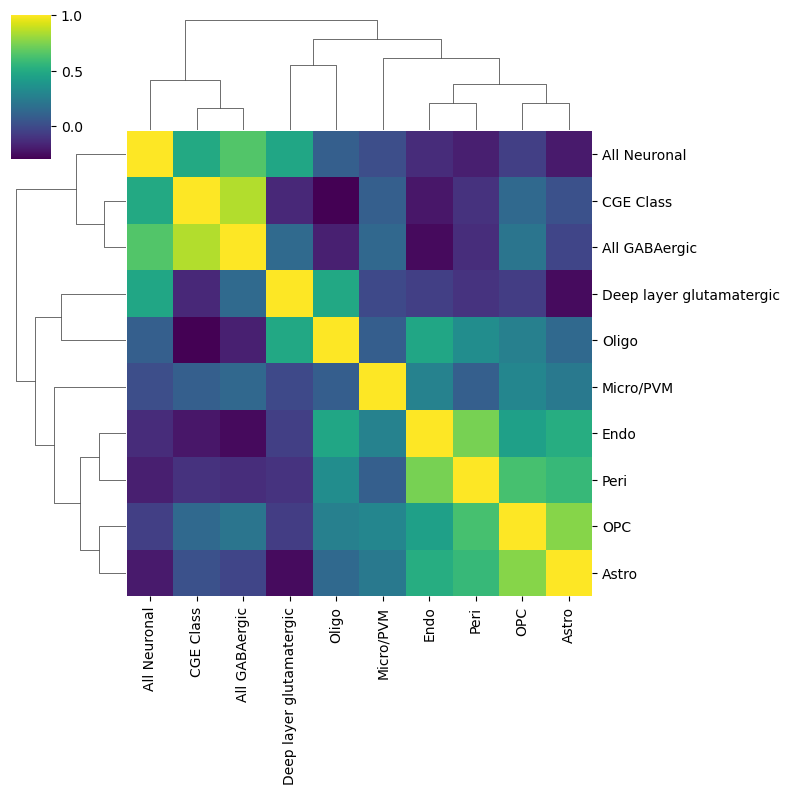

In [255]:
expr_corr_mat = ctype_abundance_df.corr()
sns.clustermap(expr_corr_mat, cmap='viridis', figsize=(8, 8))

In [ ]:
ctype_abundance_df.to_csv("data/ctype_abundance/GTEx_cortex_counts_TMMF_All_501_outliers_removed_top_Qval_mods_PC1_ctype_abundance_filtered.csv")